In [151]:
import networkx as nx
import numpy as np
import numpy.typing as npt
from scipy.sparse._csr import csr_array
from scipy.integrate import solve_ivp

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from time import time
from pdb import set_trace

In [51]:
arr64 = npt.NDArray[np.float64]

In [52]:
seed = 0
rng = np.random.default_rng(seed=seed)

# Network setup

## Sythetic
Modelling WAN from Barrat *et al.* (2004) and Colizza & Vespignani (2008)

### Structure

In [53]:
# Network structure from Barrat et al. (2004)
num_nodes = 4000
mean_degree = 10.0
degree_exponent = 2.5 # Scale free degree distribution exponent (deviated from the reference as to match mean degree)

In [54]:
# Power law degree distributions
k_min = mean_degree * (degree_exponent - 2) / (degree_exponent - 1)
u = rng.uniform(size=num_nodes)
degree_sequence = np.floor(k_min * (1 - u) ** (-1.0 / (degree_exponent - 1))).astype(int)
degree_sequence = np.maximum(1, degree_sequence)

if degree_sequence.sum() % 2 != 0:
    degree_sequence[0] += 1

In [55]:
# Delete multi-links and self-loops from configuration model
# Large degree supression ~= Physical capacity of airports
graph = nx.configuration_model(degree_sequence, seed=seed)
graph = nx.Graph(graph)
graph.remove_edges_from(nx.selfloop_edges(graph))

### Parameters

In [56]:
diffusion_coefficient = 0.0001 # w0 in Colizza & Vespignani (2008)
diffusion_exponent = 0.5 # theta in Colizza & Vespignani (2008)

for node in graph.nodes:
    graph.nodes[node]["total_pop"] = float(graph.degree[node]) # Subpopulation size propotional to out-degree

for edge in graph.edges:
    graph[edge[0]][edge[1]]["weight"] = diffusion_coefficient * (graph.degree(edge[0]) * graph.degree(edge[1])) ** diffusion_exponent # Diffusion rate d_kk' from Colizza & Vespignani (2008) Eq. 13

# Model definition
Metapopulation SIR model

## Equations

In [57]:
def get_velocity(
    time: float, 
    pop_fracs: arr64, # Population fractions array
    i_rate: np.float64, # alpha
    r_rate: np.float64, # beta
    total_pops: arr64, # N_n array
    adj_mat: csr_array, # F_nm adjacency matrix
    num_nodes: int,
) -> arr64:
    """
    Metapopulation SIR model equations
    """

    i_fracs = pop_fracs[:num_nodes] # Infected population fraction
    s_fracs = pop_fracs[num_nodes:] # Susceptible population fraction

    d_i_fracs = i_rate * s_fracs * i_fracs - r_rate * i_fracs + (adj_mat.dot(i_fracs) - adj_mat.sum(axis=0) * i_fracs) / total_pops
    d_s_fracs = -i_rate * s_fracs * i_fracs + (adj_mat.dot(s_fracs) - adj_mat.sum(axis=0) * s_fracs) / total_pops

    return np.concatenate((d_i_fracs, d_s_fracs), axis=0)

## Solver

In [58]:
def solver(
        graph: nx.DiGraph, # Population & defussion network
        # Model parameters
        reproduction: float, # R0 from Colizza & Vespignani (2008)
        removal_rate: float, # mu from Colizza & Vespignani (2008)
        # Initial points
        origin: int, # Node where infection starts
        orig_i_pop: float, # Initial infected fraction
        # Result formatting
        max_time = 1000,
        **kwargs
) -> dict:
    
    # Network parameters
    total_pops = np.array([graph.nodes[node]["total_pop"] for node in graph.nodes])
    adj_mat = nx.adjacency_matrix(graph, weight="weight", dtype=np.float64)

    # Model parameter
    infection_rate = reproduction * removal_rate

    # Initial point
    init_i_pop = np.zeros(num_nodes, dtype=np.float64)
    init_i_pop[origin] = orig_i_pop
    init_s_pop = np.ones(num_nodes, dtype = np.float64) - init_i_pop
    
    # Solve
    result = solve_ivp(
        get_velocity,
        t_span=(0, max_time),
        y0=np.concatenate((init_i_pop, init_s_pop), axis=0),
        args=(infection_rate, removal_rate, total_pops, adj_mat, num_nodes),
        **kwargs
    )

    return result

## Test

In [143]:
origin = rng.choice(graph.nodes)
result = solver(graph, 1.5, 0.05, origin, 0.001, method="RK45", atol=1e-8, rtol=1e-8)

In [144]:
result["message"]

'The solver successfully reached the end of the integration interval.'

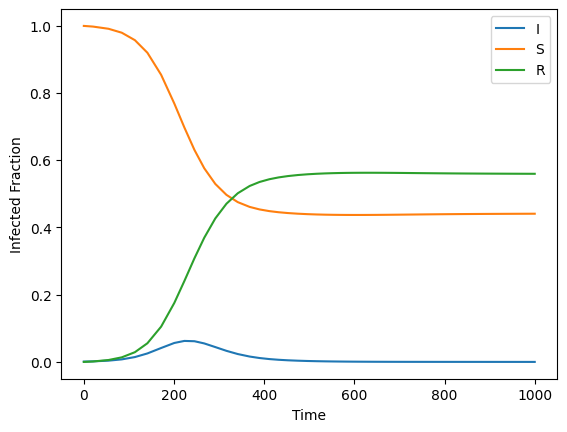

In [145]:
plt.plot(result["t"], result["y"][origin], label="I")
plt.plot(result["t"], result["y"][origin + num_nodes], label="S")
plt.plot(result["t"], 1-result["y"][origin]-result["y"][origin + num_nodes], label="R")

plt.xlabel("Time")
plt.ylabel("Infected Fraction")
plt.legend()

In [146]:
global_total_pop = 0
global_r_pop_fin = 0

for node in graph.nodes:
    global_total_pop += graph.nodes[node]["total_pop"]
    global_r_pop_fin += graph.nodes[node]["total_pop"] * (1 - result["y"][node, -1] - result["y"][node+num_nodes, -1])

global_r_pop_fin / global_total_pop

0.5666885863182319

# Percolation

In [147]:
# Model parameters
reproduction = 2.0
removal_rate = 0.04
orig_i_pop = 0.001

# Experiment parameters 
num_edge_brk_steps = 20
num_edge_brk_seeds = 10
num_origs = 10
orig_seeds = 0

# Solver parameters
method = "RK45"
max_time = 1000
tol = 1e-8

In [148]:
# Setting
num_edges = graph.number_of_edges()
edge_brk_stride = num_edges // num_edge_brk_steps 

orig_rng = np.random.default_rng(seed=orig_seeds)
orig_sequence = orig_rng.choice(graph.nodes, num_origs)

total_weight = 0
for edge in graph.edges:
    total_weight += graph[edge[0]][edge[1]]["weight"]

global_total_pop = 0
for node in graph.nodes:
    global_total_pop += graph.nodes[node]["total_pop"]

records = []

jobs = num_edge_brk_seeds * num_edge_brk_steps * num_orig
job_cnt = 0

In [ ]:
start_time = time()
# Repeat experiment for different edge breaking seed
for edge_brk_seed in range(num_edge_brk_seeds):
    brk_graph = graph.copy()

    edge_brk_rng = np.random.default_rng(seed=edge_brk_seed)
    num_edges_brk = 0
    weight_brk = 0
    
    # Cumulatively break edges 
    while num_edges_brk <= num_edges - edge_brk_stride:
        # Break edge_brk_stride edges from graph by random
        edge_brk = edge_brk_rng.choice(list(brk_graph.edges), size=edge_brk_stride, replace=False)
        brk_graph.remove_edges_from(edge_brk)

        # Record number and weight of broken edges
        num_edges_brk += edge_brk_stride
        for edge in edge_brk:
            weight_brk += graph[edge[0]][edge[1]]["weight"]

        # Repeat experiment for different origins
        for origin in orig_sequence:
            # Run solver
            result = solver(brk_graph, 2.0, 0.04, origin, 0.001, max_time=max_time, method=method, atol=tol, rtol=tol) 
            
            # Final global invasion rate 
            global_r_pop_fin = 0
            for node in graph.nodes:
                global_r_pop_fin += graph.nodes[node]["total_pop"] * (1 - result["y"][node, -1] - result["y"][node+num_nodes, -1])
            global_r_frac_fin = global_r_pop_fin / global_total_pop
            
            # Record
            row = pd.DataFrame({
                "Edge breaking seed": [edge_brk_seed],
                "Broken edge fraction": [num_edges_brk / num_edges],
                "Broken weight fraction": [weight_brk / total_weight],
                "Origin": [origin],
                "Global invasion rate": [global_r_frac_fin],
            })
            records.append(row)
            job_cnt += 1
            print(f"{job_cnt} / {jobs} done, {round(time() - start_time)} s passed")

records = pd.concat(records)
records.to_csv(f"test_R0-{reproduction}_mu-{removal_rate}_orig-pop-{orig_i_pop}.csv", index=False)

1 / 2000 done, 1 s passed
2 / 2000 done, 3 s passed
3 / 2000 done, 4 s passed
4 / 2000 done, 6 s passed
5 / 2000 done, 8 s passed
6 / 2000 done, 9 s passed
7 / 2000 done, 10 s passed
8 / 2000 done, 11 s passed
9 / 2000 done, 12 s passed
10 / 2000 done, 13 s passed
11 / 2000 done, 15 s passed
12 / 2000 done, 16 s passed
13 / 2000 done, 17 s passed
14 / 2000 done, 18 s passed
15 / 2000 done, 18 s passed
16 / 2000 done, 19 s passed
17 / 2000 done, 20 s passed
18 / 2000 done, 21 s passed
19 / 2000 done, 22 s passed
20 / 2000 done, 23 s passed
21 / 2000 done, 23 s passed
22 / 2000 done, 24 s passed
23 / 2000 done, 25 s passed
24 / 2000 done, 26 s passed
25 / 2000 done, 26 s passed
26 / 2000 done, 27 s passed
27 / 2000 done, 28 s passed
28 / 2000 done, 29 s passed
29 / 2000 done, 29 s passed
30 / 2000 done, 30 s passed
31 / 2000 done, 31 s passed
32 / 2000 done, 31 s passed
33 / 2000 done, 32 s passed
34 / 2000 done, 33 s passed
35 / 2000 done, 34 s passed
36 / 2000 done, 34 s passed
37 / 20

## Visualization

In [150]:
records = pd.read_csv("test_R0-2.0_mu-0.04_orig-pop-0.001.csv")

c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.opti

<Axes: xlabel='Broken edge fraction', ylabel='Global invasion rate'>

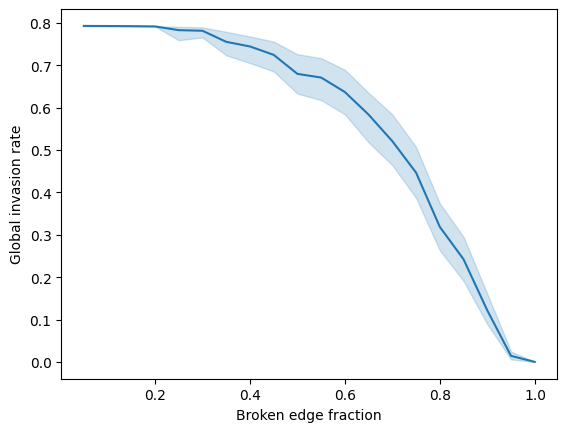

In [152]:
sns.lineplot(data=records, x="Broken edge fraction", y="Global invasion rate")

c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.opti

<Axes: xlabel='Broken weight fraction', ylabel='Global invasion rate'>

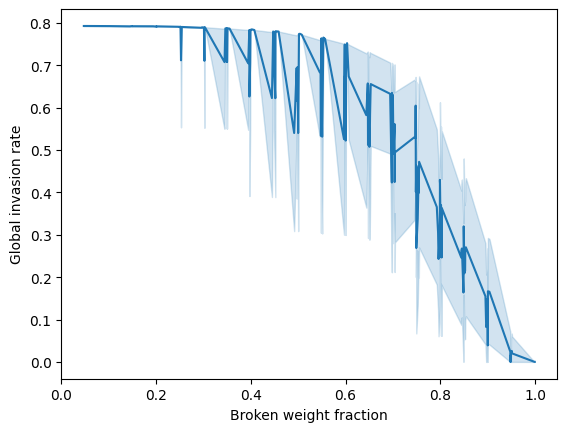

In [153]:
sns.lineplot(data=records, x="Broken weight fraction", y="Global invasion rate")